# Numerical Optimization With Python

*Contributors: Dr Yae GABA; Dr Aurelle TCHAGNA; Mr. Domini LEKO*

# Assignment_Week_Numerical Optimization


## Instructions

* This test contains **5** questions each of which should be answered.
* Write your program in a Python cell just under each question.
* You should write an explanation of your solution as comments in your code.
* In each case your solution program must fulfil all of the instructions. Please check the instructions carefully and double check that your program fulfils all of the given instructions.
* Save your work regularly.

In [282]:

import numpy as np
import scipy.linalg as sl

## Question 1

Consider the expression
\begin{equation}
f(x) = x \mathrm{sin}(\pi x)-\mathrm{e}^{-x}.
\end{equation}

 1. Write a function, $f$,  to evaluate this expression for a given $x$. Show that it works by plotting the function with respect to $100$ evenly spaced points between $x=-3$ and $x=3$.
 2. Write another function, $g$ that uses central finite differences to numerically evaluate the derivative of an arbitrary given function with respect to $x$ (you may assume $dx\approx0.01$). Show that it works by plotting the derivative of the function defined above between $x=-3$ and $x=3$. 
 3. Write a function that implements Newton's method for root finding. It should take as input parameters a function, $f$, whose root is to be found, its derivative function, $g$, and an initial guess, $x0$.
 4. Use your implementation of Newton's method to calculate all the roots of $f$ between $-3$ and $3$.

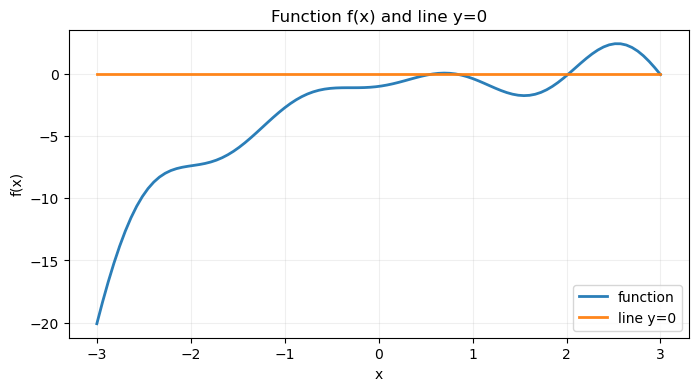

In [283]:
# put your code here

# Question 1)
def f(x):
    return x * np.sin(np.pi * x) - np.exp(-x)

import matplotlib.pyplot as plt
x = np.linspace(-3, 3, 100)
y = f(x)
z = np.zeros_like(x)
plt.figure(figsize=(8,4))
plt.plot(x, y, label="function", alpha=0.95, linewidth=2)
plt.plot(x, z, label="line y=0", alpha=0.95, linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function f(x) and line y=0")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

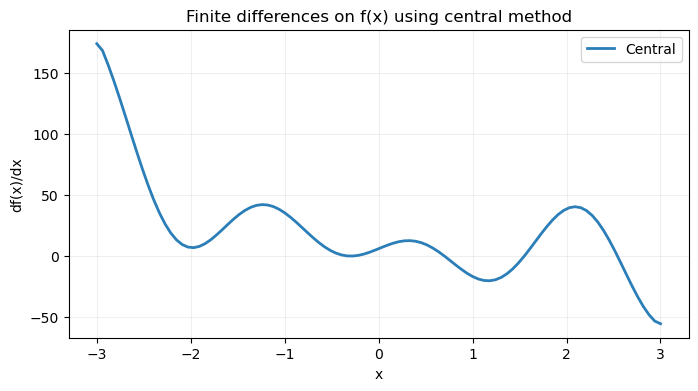

In [284]:
# Question 2)


def g(x, h=0.01):
    x = np.asarray(x, dtype=float)
    d = np.empty_like(x, dtype=float)
    d[0]  = (x[1] - x[0]) / h
    d[-1] = (x[-1] - x[-2]) / h
    d[1:-1] = (x[2:] - x[:-2]) / (2*h)
    return d

x = np.linspace(-3, 3, 100)
dx_c = g(y)

plt.figure(figsize=(8,4))
plt.plot(x, dx_c, label="Central", alpha=0.95, linewidth=2)
plt.xlabel("x")
plt.ylabel("df(x)/dx")
plt.title("Finite differences on f(x) using central method")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

In [285]:
# Question 3) 

def newton(f, g, x0):
    history = []
    x = float(x0)

    tol_x=1e-10
    tol_f=1e-12, 
    max_iter=50
    return_history=True
    for k in range(max_iter):
        fx = f(x)
        dfx = g(x)
        if dfx == 0:
            raise ZeroDivisionError("Newton failed: derivative is zero.")
        x_new = x - fx/dfx

        if return_history:
            history.append((k, x, fx, dfx, x_new, abs(x_new-x)))

        if abs(f(x_new)) <= tol_f or abs(x_new - x) <= tol_x:
            return (x_new, history) if return_history else x_new

        x = x_new
    return (x, history) if return_history else x

In [286]:
# Question 4)

def df(x):
    return np.sin(np.pi*x) + x*np.pi*np.cos(np.pi*x) + np.exp(-x)

def all_root(f, df):
    root_vector = []
    x = np.linspace(-3, 3, 100)
    for i in range(len(x)-1):
        if (f(x[i])*f(x[i+1]) < 0):
            x0 = (x[i] + x[i+1])/2
            #apply newton
            x_newt, hist_newt = newton(f, df, x0)
            if (x_newt not in root_vector):
                root_vector.append(x_newt)
    return root_vector
            
        
root = all_root(f, df)
print("All root of f are:", root)

All root of f are: [0.5782625778645154, 0.8191177934425946, 2.0208909077713524, 2.9946795645231936]


## Question 2: singular matrices and ill-conditioning 

For the following matrixes, compute the determinant and the condition number, and classify them as singular, ill conditioned or well conditioned:
$$ (i)\quad A = 
  \begin{pmatrix}
    1 & 2 & 3 \\
    2 & 3 & 4 \\
    3 & 4 & 5 \\
  \end{pmatrix}
\quad\quad\quad\quad
(ii)\quad A = 
  \begin{pmatrix}
    2.11 & -0.80 & 1.72 \\
    -1.84 & 3.03 & 1.29 \\
    -1.57 & 5.25 & 4.30 \\
  \end{pmatrix}
$$
$$ (iii)\quad A = 
  \begin{pmatrix}
    2 & -1 & 0 \\
    -1 & 2 & -1 \\
    0 & -1 & 2 \\
  \end{pmatrix}
\quad\quad\quad\quad
(iv)\quad A = 
  \begin{pmatrix}
    4 & 3 & -1 \\
    7 & -2 & 3 \\
    5 & -18 & 13 \\
  \end{pmatrix}\,.
$$


In [287]:
# put your code here

#Definition of matrix
A1 = np.array([[1,2,3], [2,3,4], [3,4,5]])
A2 = np.array([[2.11, -0.80, 1.72], [-1.84, 3.03, 1.29], [-1.57, 5.25, 4.30]])
A3 = np.array([[2, -1, 0], [-1, 2, -1], [0, -1, 2]])
A4 = np.array([[4, 3, -1], [7, -2, 3], [5, -18, 13]])

print("determinant of A1: det(A1) = {} \ncondition number: cond(A1) = {}".format(sl.det(A1), np.linalg.cond(A1)))
print('=====')
print("determinant of A2: det(A2) = {} \ncondition number: cond(A2) = {}".format(sl.det(A2), np.linalg.cond(A2)))
print('=====')
print("determinant of A3: det(A3) = {} \ncondition number: cond(A3) = {}".format(sl.det(A3), np.linalg.cond(A3)))
print('=====')
print("determinant of A4: det(A4) = {} \ncondition number: cond(A4) = {}".format(sl.det(A4), np.linalg.cond(A4)))
print('=====')
print("Singular and ill condition: A1 and A4")
print('=====')
print("Not singular and ill condition: A2")
print('=====')
print("Not singular and well condition: A3")

determinant of A1: det(A1) = -7.40148683083438e-17 
condition number: cond(A1) = 4.065294633547468e+16
=====
determinant of A2: det(A2) = 0.05886699999999918 
condition number: cond(A2) = 3218.3325414808673
=====
determinant of A3: det(A3) = 4.0 
condition number: cond(A3) = 5.828427124746193
=====
determinant of A4: det(A4) = -1.4488410471358293e-14 
condition number: cond(A4) = 5.627312320109326e+16
=====
Singular and ill condition: A1 and A4
=====
Not singular and ill condition: A2
=====
Not singular and well condition: A3


## Question 3

Consider the list of x, y values:
```python
data = [[-0.9337935465228038, -0.07232476432206313], [-0.8579378359997711, -0.13887855006418778], [-0.9335374315243639, -0.06891805360643874], [-0.7687972106343928, 0.47854185044762787], [-0.7306837856905433, -0.47459494645121353], [-0.6828439321703356, -0.41364008798454377], [-1.0453664566329348, 0.19076506315493422], [-0.7456706490538763, -0.16083773809180218], [-0.7901894271258242, -0.35580360448848314], [-0.8928261346578745, -0.11441585592065782], [-0.841112498251017, 0.11011089888857295], [-0.7623488411754865, 0.18998754343916874], [-0.6925391941737394, -0.13413672359866718], [-0.6902708987539867, 0.03828838507783988], [-0.6687088543845848, -0.19894131765469594], [-0.6665302769372866, -0.1029760373482482], [-0.6420064312909557, -0.6554448913215021], [-0.5758230731110595, -0.5507175277632846], [-0.5756193577065919, -0.34173252704827584], [-0.4792448826592391, -0.7787912310124582], [-0.6408469813365063, -0.12147511680925833], [-0.5280178683517309, -0.5925774412972209], [-0.40380128700592666, 0.20900480487662598], [-0.4984729502442131, -0.7298392143009301], [-0.5446041323420464, -0.1640781007153601], [-0.48747960814661245, -0.261758542806879], [-0.5799087987763005, 0.01804472171650212], [-0.6001204968913751, -0.5173128958933764], [-0.5408366062285066, 0.2537613288571337], [-0.38110795902977784, -0.07330724873760994], [-0.5422499914727943, 0.021055251264383623], [-0.3588024164475623, -0.755308535619374], [-0.33248783543679084, -0.008535064734786574], [-0.5582457235994508, -0.4842740932690006], [-0.3221863564430907, 0.1525219788206888], [-0.3376212171114362, -0.15341217619428396], [-0.39166347962454356, -0.6316948130034112], [-0.23787007932215568, -0.626007030754575], [-0.12822641744709634, -0.49711343442847833], [-0.28780735187386897, -0.37401187442144845], [-0.2256289613091519, 0.42738543296089865], [-0.20967109085646085, -0.619832692105101], [0.049888337755669365, 0.07915019745819946], [-0.29567608376539767, -0.31023915589187206], [-0.026948425628742695, 0.25493770689048956], [-0.12691953366494887, -0.000909766036063589], [0.0644530895546884, -0.205614968739875], [-0.05421300377705436, 0.211270578336775], [-0.06773437907785596, -0.09404837529816071], [-0.08781953252002822, 0.4950172941365908], [0.1699783081462978, 0.04161833622202843], [-0.015524186031637438, 0.22888636161025255], [0.008431200904915698, -0.02428090691926993], [-0.012386785181722981, 0.09795380692075228], [0.1277714124907157, -0.1874700571343013], [0.05054549789429795, 0.01592527917293688], [0.22749579269721798, 0.36379096097487046], [0.13743820699257583, -0.13891144826473859], [0.011471149555491, 0.1596722795790772], [0.05940794372674682, -0.32432081194482404], [0.13757854768355646, 0.3445671139522366], [0.1647342343696234, -0.48672945291370273], [0.3901805474982435, 0.6740568752219067], [0.33397353376989003, 0.12542170513026485], [0.27723736088095224, -0.03880151513955743], [0.38027666377788694, 0.7188557769489713], [0.3039163622444417, 0.07299778741917612], [0.6206624890731296, 0.9760489756301297], [0.5179747935391051, 0.3641031631630265], [0.4923430557432943, 0.9238785497199989], [0.46780794329346204, 0.6315111432675516], [0.4349339208558625, 0.3845871247746798], [0.45053806993654766, 0.6847996631379732], [0.21407435217987014, 0.3125141886595262], [0.5936872371231747, 0.7140765515168056], [0.6143326130353116, 1.1045884421566523], [0.45210706477963847, 0.727440701294205], [0.48206791039922003, 0.0717294265808559], [0.6436467903498477, 0.747405161550199], [0.6217065866496854, 0.39358816921264717], [0.5077833980215545, 0.674852145544422], [0.5745755859495608, 1.217034240831342], [0.7945208778948454, 0.9388653585165085], [0.6874241835639029, 1.069054319183201], [0.7488172156422873, 1.3002883281857642], [0.7607457564824649, 1.1948244526119254], [0.7462485211152293, 1.2638984837102047], [0.8087906167850747, 1.6545261032878231], [0.9132613752044277, 1.51614396744652], [0.8457699554666472, 1.4824871685995005], [0.5402299927752592, 0.6045922483701612], [0.7770802222320328, 1.312219056607684], [0.5727071199546903, 0.9936874484935464], [0.8076276071584211, 1.9310943625200159], [0.9755851889094171, 2.330122777836598], [0.7543547773142139, 1.5118303380132634], [1.060512671008649, 2.1901761853146957], [1.0912226101509486, 2.0810305800930875], [0.9349382603088677, 2.356766292026297], [0.9474314681471394, 2.0685863572622636]]
```
1.  Fit polynomials of orders 0, 1, 2 and 3 to the data. Plot the raw point data and each of the polynomials.  <sub>[20 marks]</sub>
* Print out the error of each polynomil fit, where the error is defined as the sum of the squares of the differences between the data provided and the polynomial,$$E = \sum_{i=0}^{N} (p(x_i) - y_i)^2,$$ where $p(x_i)$ is the value of the polynomial function that has been fit to the data evaluated at point $x_i$, and $y_i$ is the $i^{th}$ data value.
* Fit a 10th order polynomial to the data. Plot the polynomial from x=-1.2 to x=1.2 and print out the error. Is this a better representation of the data; justify your answer. 

poly_coeffs0:  [0.30717922]
poly_coeffs1:  [1.02331464 0.30155551]
poly_coeffs2:  [ 1.15710316  0.96122071 -0.08326274]
poly_coeffs3:  [ 0.12325108  1.14428215  0.88895688 -0.0810248 ]


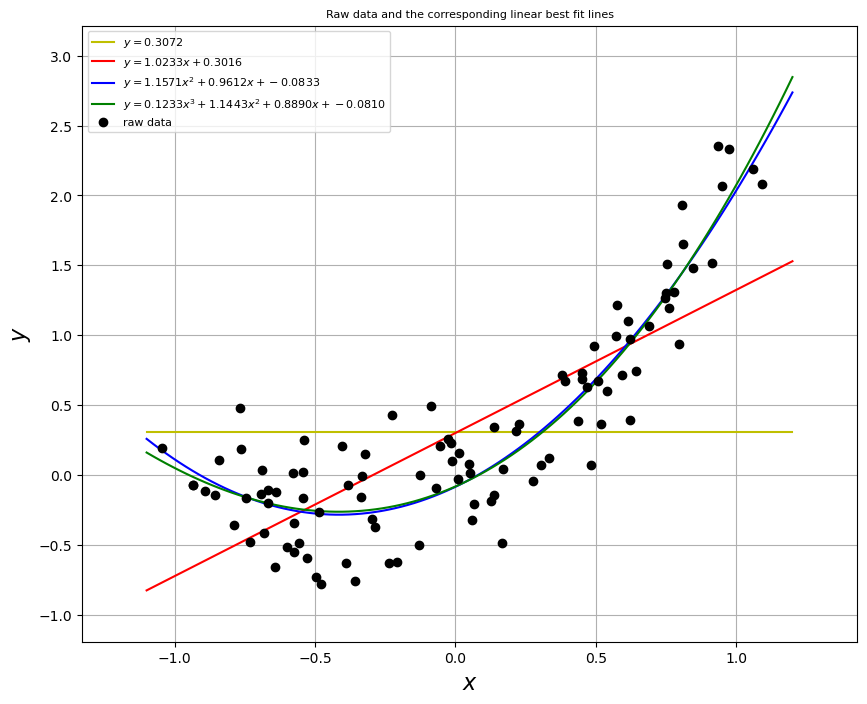

In [288]:
data = [[-0.9337935465228038, -0.07232476432206313], [-0.8579378359997711, -0.13887855006418778], [-0.9335374315243639, -0.06891805360643874], [-0.7687972106343928, 0.47854185044762787], [-0.7306837856905433, -0.47459494645121353], [-0.6828439321703356, -0.41364008798454377], [-1.0453664566329348, 0.19076506315493422], [-0.7456706490538763, -0.16083773809180218], [-0.7901894271258242, -0.35580360448848314], [-0.8928261346578745, -0.11441585592065782], [-0.841112498251017, 0.11011089888857295], [-0.7623488411754865, 0.18998754343916874], [-0.6925391941737394, -0.13413672359866718], [-0.6902708987539867, 0.03828838507783988], [-0.6687088543845848, -0.19894131765469594], [-0.6665302769372866, -0.1029760373482482], [-0.6420064312909557, -0.6554448913215021], [-0.5758230731110595, -0.5507175277632846], [-0.5756193577065919, -0.34173252704827584], [-0.4792448826592391, -0.7787912310124582], [-0.6408469813365063, -0.12147511680925833], [-0.5280178683517309, -0.5925774412972209], [-0.40380128700592666, 0.20900480487662598], [-0.4984729502442131, -0.7298392143009301], [-0.5446041323420464, -0.1640781007153601], [-0.48747960814661245, -0.261758542806879], [-0.5799087987763005, 0.01804472171650212], [-0.6001204968913751, -0.5173128958933764], [-0.5408366062285066, 0.2537613288571337], [-0.38110795902977784, -0.07330724873760994], [-0.5422499914727943, 0.021055251264383623], [-0.3588024164475623, -0.755308535619374], [-0.33248783543679084, -0.008535064734786574], [-0.5582457235994508, -0.4842740932690006], [-0.3221863564430907, 0.1525219788206888], [-0.3376212171114362, -0.15341217619428396], [-0.39166347962454356, -0.6316948130034112], [-0.23787007932215568, -0.626007030754575], [-0.12822641744709634, -0.49711343442847833], [-0.28780735187386897, -0.37401187442144845], [-0.2256289613091519, 0.42738543296089865], [-0.20967109085646085, -0.619832692105101], [0.049888337755669365, 0.07915019745819946], [-0.29567608376539767, -0.31023915589187206], [-0.026948425628742695, 0.25493770689048956], [-0.12691953366494887, -0.000909766036063589], [0.0644530895546884, -0.205614968739875], [-0.05421300377705436, 0.211270578336775], [-0.06773437907785596, -0.09404837529816071], [-0.08781953252002822, 0.4950172941365908], [0.1699783081462978, 0.04161833622202843], [-0.015524186031637438, 0.22888636161025255], [0.008431200904915698, -0.02428090691926993], [-0.012386785181722981, 0.09795380692075228], [0.1277714124907157, -0.1874700571343013], [0.05054549789429795, 0.01592527917293688], [0.22749579269721798, 0.36379096097487046], [0.13743820699257583, -0.13891144826473859], [0.011471149555491, 0.1596722795790772], [0.05940794372674682, -0.32432081194482404], [0.13757854768355646, 0.3445671139522366], [0.1647342343696234, -0.48672945291370273], [0.3901805474982435, 0.6740568752219067], [0.33397353376989003, 0.12542170513026485], [0.27723736088095224, -0.03880151513955743], [0.38027666377788694, 0.7188557769489713], [0.3039163622444417, 0.07299778741917612], [0.6206624890731296, 0.9760489756301297], [0.5179747935391051, 0.3641031631630265], [0.4923430557432943, 0.9238785497199989], [0.46780794329346204, 0.6315111432675516], [0.4349339208558625, 0.3845871247746798], [0.45053806993654766, 0.6847996631379732], [0.21407435217987014, 0.3125141886595262], [0.5936872371231747, 0.7140765515168056], [0.6143326130353116, 1.1045884421566523], [0.45210706477963847, 0.727440701294205], [0.48206791039922003, 0.0717294265808559], [0.6436467903498477, 0.747405161550199], [0.6217065866496854, 0.39358816921264717], [0.5077833980215545, 0.674852145544422], [0.5745755859495608, 1.217034240831342], [0.7945208778948454, 0.9388653585165085], [0.6874241835639029, 1.069054319183201], [0.7488172156422873, 1.3002883281857642], [0.7607457564824649, 1.1948244526119254], [0.7462485211152293, 1.2638984837102047], [0.8087906167850747, 1.6545261032878231], [0.9132613752044277, 1.51614396744652], [0.8457699554666472, 1.4824871685995005], [0.5402299927752592, 0.6045922483701612], [0.7770802222320328, 1.312219056607684], [0.5727071199546903, 0.9936874484935464], [0.8076276071584211, 1.9310943625200159], [0.9755851889094171, 2.330122777836598], [0.7543547773142139, 1.5118303380132634], [1.060512671008649, 2.1901761853146957], [1.0912226101509486, 2.0810305800930875], [0.9349382603088677, 2.356766292026297], [0.9474314681471394, 2.0685863572622636]]

# Definition of xi and yi
xi = np.zeros(len(data))
yi = np.zeros(len(data))
for i in range(len(data)):
    xi[i] = data[i][0]
    yi[i] = data[i][1]

# Fit a polynomial of degree n, i.e. a straight line, to our (xi, yi) data from above
degree1 = 1
degree2 = 2
degree3 = 3
poly_coeffs0 = np.polyfit(xi, yi, 0)
poly_coeffs1 = np.polyfit(xi, yi, degree1)
poly_coeffs2 = np.polyfit(xi, yi, degree2)
poly_coeffs3 = np.polyfit(xi, yi, degree3)
print('poly_coeffs0: ',poly_coeffs0)
print('poly_coeffs1: ',poly_coeffs1)
print('poly_coeffs2: ',poly_coeffs2)
print('poly_coeffs3: ',poly_coeffs3)

# use poly1d to turn the coeffs into a function, pn, we can evaluate
p0 = np.poly1d(poly_coeffs0)
p1 = np.poly1d(poly_coeffs1)
p2 = np.poly1d(poly_coeffs2)
p3 = np.poly1d(poly_coeffs3)

# set up figure
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(111)
ax1.margins(0.1)

# Plot the linear fit - define 100 evenly spaced points (x) covering our
# x extent and plot our linear polynomial evaluated at these points (pn(x))
# of course 100 is overkill for this linear example
x = np.linspace(-1.1, 1.2, 100)

ax1.plot(x, p0(x), 'y', label=r'$y = {0:.4f}$'.format(poly_coeffs0[0]))
ax1.plot(x, p1(x), 'r', label=r'$y = {0:.4f}x+{1:.4f}$'.format(poly_coeffs1[0], poly_coeffs1[1]))
ax1.plot(x, p2(x), 'b', label=r'$y ={0:.4f}x^2 +{1:.4f}x+{2:.4f}$'.format(poly_coeffs2[0], poly_coeffs2[1], poly_coeffs2[2]))
ax1.plot(x, p3(x), 'g', label=r'$y ={0:.4f}x^3 +{1:.4f}x^2 +{2:.4f}x + {3:.4f}$'.format(poly_coeffs3[0], poly_coeffs3[1], poly_coeffs3[2], poly_coeffs3[3]))

# Overlay raw data
plot_raw_data(xi, yi, ax1)

# Add a legend
ax1.legend(loc='best', fontsize=8)

# add a figure title
ax1.set_title('Raw data and the corresponding linear best fit lines', fontsize=8);

In [289]:
# Print out the error of each polynomil fit

def error(p):
    error = 0
    for k in range(100):
        error = error + (p(xi[k]) - yi[k]) ** 2
    return error
print("====================================")
print('error of p0: ',error(p0))
print('error of p1: ',error(p1))
print('error of p2: ',error(p2))
print('error of p3: ',error(p3))


error of p0:  54.62753491233334
error of p1:  19.773946100330264
error of p2:  8.34597036337077
error of p3:  8.304822541013555


poly_coeffs10:  [ 1.74807261e+00 -1.47291689e+01 -2.38424494e+00  3.52637444e+01
 -1.63930614e+00 -2.80518965e+01  3.61408551e+00  8.58831302e+00
 -2.15258293e-01  1.22462053e-01 -2.10442033e-03]
error of p10: 7.551314385591968 
 This polynomial is better than the previous ones because its error is smaller. 
However, it is not well-suited for data representation because its error is still large.


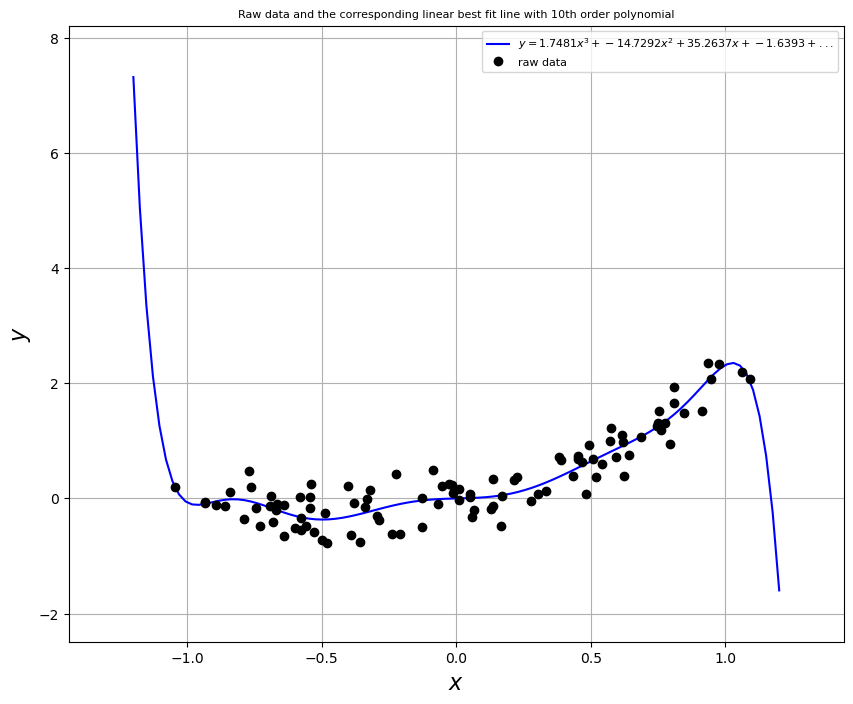

In [290]:
#Fit a 10th order polynomial to the data

degree = 10
poly_coeffs = np.polyfit(xi, yi, degree)
print("====================================")
print('poly_coeffs10: ',poly_coeffs)

# use poly1d to turn the coeffs into a function, p10, we can evaluate
p10 = np.poly1d(poly_coeffs)

# set up figure
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(111)
ax1.margins(0.1)

x = np.linspace(-1.2, 1.2, 100)

ax1.plot(x, p10(x), 'b', label=r'$y ={0:.4f}x^3 +{1:.4f}x^2 +{2:.4f}x + {3:.4f}+...$'.format(poly_coeffs[0], poly_coeffs[1], poly_coeffs[3], poly_coeffs[4]))

# Overlay raw data
plot_raw_data(xi, yi, ax1)

# Add a legend
ax1.legend(loc='best', fontsize=8)

# add a figure title
ax1.set_title('Raw data and the corresponding linear best fit line with 10th order polynomial', fontsize=8);

print("====================================")
print('''error of p10: {} \n This polynomial is better than the previous ones because its error is smaller. 
However, it is not well-suited for data representation because its error is still large.'''.format(error(p10)))

## Question 4

Below is a extract of shot data from a seismic survey.

|  Time (ms)  |  Shot  |
|-----|-----|
| 0 | -0.021373 |
| 4 | -0.024578 |
| 8 | -0.023914 |
| 12 | -0.018227 |
| 16 | -0.00781 |
| 20 | 0.005602 |
| 24 | 0.019264 |
| 28 | 0.030235 |
| 32 | 0.036059 |
| 36 | 0.035334 |

 1. Calculate the Lagrange polynomial for these points. Plot both the Lagrange polynomial and the raw data points.
 2. The full shot is available in the file [shot.txt](data/shot.txt) (in the data folder) - where the sample interval is 4ms as above. Note that the file only contains one column as you can calculate the time column yourself. Use cubic-polynomial splines to re-interpolate the data for a sample interval of 7.07ms. Plot both the original shot data and the interpolated time series.


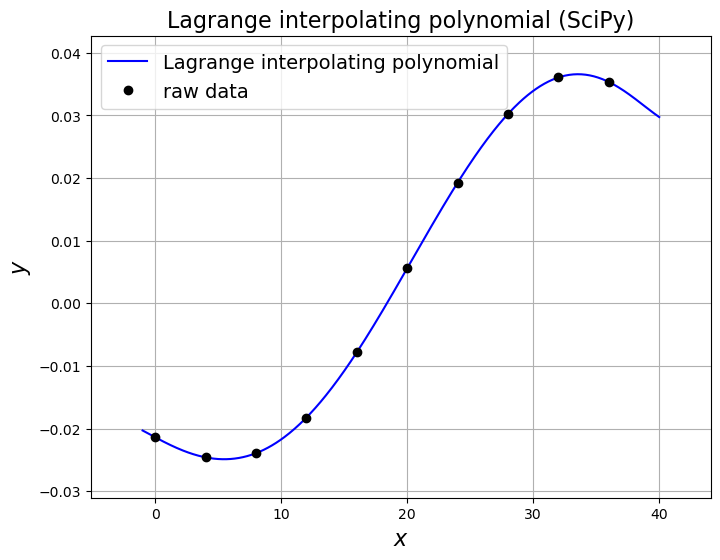

In [291]:
# put your code here

# Question 1)

import scipy.interpolate as si

### Our raw data from earlier - you can also test on our three data point example
xi = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32, 36])
yi = np.array([-0.021373, -0.024578, -0.023914, -0.018227, -0.00781, 0.005602, 0.019264,0.030235, 0.036059, 0.035334])

# Create the Lagrange polynomial for the given points.
lp = si.lagrange(xi, yi)
# above we executed 'import scipy.interpolate as si'
# and so this line is calling the 'lagrange' function from the 
# 'interpolate' sub-package within scipy.

# Evaluate this function at a high resolution (100 points here) so that 
# we get a smooth well-resolved line when we plot our polynomial
x = np.linspace(-1, 40, 500)

# set up the figure
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
ax1.margins(0.1)

# actually plot (x,y)=(x,lp(x)) on the axes with the label ax1
ax1.plot(x, lp(x), 'b', label='Lagrange interpolating polynomial')

# Overlay raw data on the same axes
plot_raw_data(xi, yi, ax1)
ax1.set_title('Lagrange interpolating polynomial (SciPy)', fontsize=16)

# Add a legend
ax1.legend(loc='best', fontsize=14);

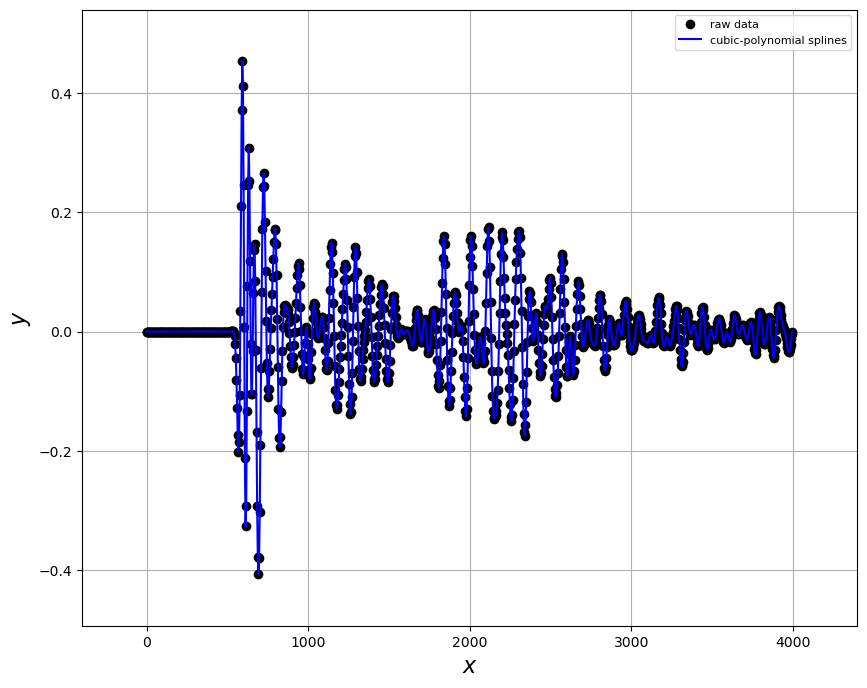

In [292]:
# Question 2)

import pandas as pd

times = []
shots = pd.read_csv('shot.txt')
for i in range(len(shots)):
    times.append(i*4)
    
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(111)
ax1.margins(0.1)
plot_raw_data(times, shots, ax1)

times1 = [i + 7.07 for i in times]
cubic = si.CubicSpline(times1, shots)

ax1.plot(times, cubic(times1), 'b', label='cubic-polynomial splines')

# Add a legend
ax1.legend(loc='best', fontsize=8);

## Question 5

Consider the usual linear system $A\pmb{x} = \pmb{b}$, of dimension $n$, where $\pmb{x}$ is the unknown vector, $A$ is a given square matrix and $\pmb{b}$ is a given vector.

The weighted Jacobi method is a variant of Jacobi's method to solve a linear system of equations. The idea of the modified algorithm is to take the new value of $\pmb{x}$ as a weighted average of its previous value and the value predicted by the regular Jacobi iteration. In other words the $k^{th}$ iteration of the algorithm is changed into:
$$x_i^{(k)} = \frac{\omega}{A_{ii}}\left(b_i- \sum_{\substack{j=1\\ j\ne i}}^nA_{ij}x_j^{(k-1)}\right) + (1-\omega)x_i^{(k-1)},\quad  i=1,2,\ldots, n.$$



1. Explain what the algorithm does for $\omega = 0$ and for $\omega = 1$. <sub>[10 marks]</sub>

2. Write a function that solves a system with the weighted Jacobi's algorithm, for given $A$, $\pmb{b}$ and $\omega$. <sub>[10 marks]</sub>

3. Consider the following linear system:
$$  
\left\{
\begin{array}{lcl}
  10 x_1 - x_2 + 2 x_3  &=& 6 \\ 
  - x_1 +  11 x_2 - x_3 + 3 x_4 &=& 25 \\ 
  2 x_1  - x_2 + 10 x_3 - x_4 &=& -11 \\
           3 x_2 - x_3 + 8 x_4 &=& 15 
  \end{array}
\right.
$$
Write this system in matrix form. Verify that there is one and only one solution. 

4. Solve the previous problem using your weighted Jacobi function for $\omega = 0.5$ to a tolerance of $10^{-4}$, and check your answer. 

5. Solve the previous problem with the weighted Jacobi method, for $\omega = 0.3, 0.5, 0.7, 0.8, 0.9, 0.95$ and $1$. Perform 10 iterations of the weighted Jacobi algorithm. On the same plot, plot the residual as a function of the jacobi iteration number for each $\omega$. Deduce the best value for $\omega$ among the proposed values.



In [293]:
#Question 1)

print('''If w = 0, we have x_i^k = x_i^{k-1}. The algorithm does not perform any updates.There is no convergence unless the initial point is already
  a solution.''')
print("If w = 1, We have the standard Jacobi method. All new values used depend on the values from the previous iteration.") 

If w = 0, we have x_i^k = x_i^{k-1}. The algorithm does not perform any updates.There is no convergence unless the initial point is already
  a solution.
If w = 1, We have the standard Jacobi method. All new values used depend on the values from the previous iteration.


In [294]:
# Question 2)

def solve(A,b,w, tol, iterations):
    # an initial guess at the solution - here just a vector of zeros of length the number of rows in A
    x = np.zeros(A.shape[0]) 

    # specify an upper limit on the number of iterations - if we don't hit tolerance
    # then stop the algorithm, so that it doesn't go on for ever potentially
    #it_max = 1000

    # for later plotting let's start a list to store the residuals
    residuals=[] 

    # now iterate
    for it in range(it_max):
        x_new = np.zeros(A.shape[0])  # initialise the new solution vector
        for i in range(A.shape[0]):
            x_new[i] = (w/A[i, i]) * (b[i] 
                                   - (np.dot(A[i, :i], x[:i]) 
                                   + np.dot(A[i, i+1:], x[i+1:]))) + (1-w) * x[i]

        residual = sl.norm(A @ x - b)  # calculate the norm of the residual r=Ax-b for this latest guess
        residuals.append(residual) # store it for later plotting
        if (residual < tol): # if less than our required tolerance jump out of the iteration and end.
            break

        x = x_new # update old solution

    # print out the number of iterations, 
    # if this is it_max we know the algorithm didn't actually converge
    #print('Total number of iterations: ', it)

    return x_new, residuals  #our solution vector and residuals

In [295]:
# Question 3)

A = np.array([[10, -1, 2, 0], [-1, 11, -1, 3], [2, -1, 10, -1], [0, 3, -1, 8]])
b = np.array([6, 25, -11, 15])

det = sl.det(A1)

print("The determinant of A: {} is different than 0. So this system has a unit solution.".format(det))

The determinant of A: -7.40148683083438e-17 is different than 0. So this system has a unit solution.


In [296]:
# Question 4)

sol = solve(A,b,w=0.5, tol = 1.e-4, iterations = 1000)
print(sol[0])

Excat_value = sl.inv(A) @ b
print(Excat_value)  # check the answer

[ 0.90200238  1.90111496 -0.93426596  1.10708261]
[ 1.  2. -1.  1.]


For w = 0.3, we have: [ 0.69395502  1.68015123 -0.81346734  1.12825675]
For w = 0.5, we have: [ 0.90200238  1.90111496 -0.93426596  1.10708261]
For w = 0.7, we have: [ 0.97531263  1.96698409 -0.98011118  1.04176252]
For w = 0.8, we have: [ 0.98836237  1.98225119 -0.99076043  1.02249011]
For w = 0.9, we have: [ 0.99376753  1.99323776 -0.99766605  1.01302166]
For w = 0.95, we have: [ 0.99317379  2.00023328 -1.00230563  1.01389583]
For w = 1, we have: [ 0.9889913   2.01141473 -1.0102859   1.02135051]


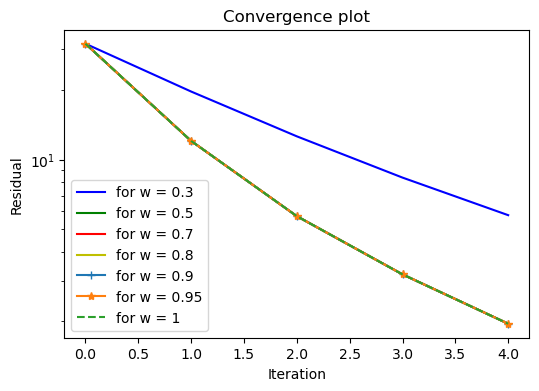

Error for w = 0.3 is:  0.24721099486543954
Error for w = 0.5 is:  0.03516943550227091
Error for w = 0.7 is:  0.003839189824791713
Error for w = 0.8 is:  0.001041629459495248
Error for w = 0.9 is:  0.00025958252339792825
Error for w = 0.95 is:  0.00024506154408760475
Error for w = 1 is:  0.0008131315036191813


In [297]:
# Question 5)

print("For w = {}, we have: {}".format(0.3, solve(A,b,w=0.3, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(0.5, solve(A,b,w=0.5, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(0.7, solve(A,b,w=0.7, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(0.8, solve(A,b,w=0.8, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(0.9, solve(A,b,w=0.9, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(0.95, solve(A,b,w=0.95, tol = 1.e-4, iterations = 10)[0]))
print("For w = {}, we have: {}".format(1, solve(A,b,w=1, tol = 1.e-4, iterations = 10)[0]))

x_new0, residuals0 =  solve1(A,b,w=0.3, tol=1.e-4, iterations=10)
x_new1, residuals1 =  solve1(A,b,w=0.5, tol=1.e-4, iterations=10)
x_new2, residuals2 =  solve1(A,b,w=0.7, tol=1.e-4, iterations=10)
x_new3, residuals3 =  solve1(A,b,w=0.8, tol=1.e-4, iterations=10)
x_new4, residuals4 =  solve1(A,b,w=0.9, tol=1.e-4, iterations=10)
x_new5, residuals5 =  solve1(A,b,w=0.95, tol=1.e-4, iterations=10)
x_new6, residuals6 =  solve1(A,b,w=1, tol=1.e-4, iterations=10)

# plot the log of the residual against iteration number 
fig = plt.figure(figsize=(6, 4))
ax1 = plt.subplot(111)
ax1.semilogy(residuals0, 'b', label='for w = 0.3') # plot the log of the residual against iteration number 
ax1.semilogy(residuals1, 'g', label='for w = 0.5') 
ax1.semilogy(residuals1, 'r', label='for w = 0.7')
ax1.semilogy(residuals1, 'y', label='for w = 0.8')
ax1.semilogy(residuals1, '+-', label='for w = 0.9')
ax1.semilogy(residuals1, '*-', label='for w = 0.95')
ax1.semilogy(residuals1, '--', label='for w = 1')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Residual')
ax1.set_title('Convergence plot')
plt.legend()
plt.show()

def error(sol):
    error = 0
    for k in range(len(Excat_value)):
        error = error + (sol[k] - Excat_value[k]) ** 2
    return error

print("Error for w = 0.3 is: ", error(x_new0))
print("Error for w = 0.5 is: ", error(x_new1))
print("Error for w = 0.7 is: ", error(x_new2))
print("Error for w = 0.8 is: ", error(x_new3))
print("Error for w = 0.9 is: ", error(x_new4))
print("Error for w = 0.95 is: ", error(x_new5))
print("Error for w = 1 is: ", error(x_new6))


In [298]:
print("We deduce that the best value for w is:", 0.95)

We deduce that the best value for w is: 0.95
